# RASID — AI-Powered Early Warning System for Supply Chain Disruption Risk

## Project Objective

RASID is a machine learning project that predicts the next day's supply chain disruption risk using the previous 7 days of supplier and operational data.

The target variable is `Risk_Level`, with three classes:

* High
* Medium
* Low

The project uses time-series data from multiple suppliers and compares different machine learning models to select a final model based on validation and test performance.


## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine learning models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import os
import json
import joblib


## 2. Data Loading & Preparation

In [2]:
# Load the dataset
df = pd.read_csv("supply_20000.csv")

# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort data by supplier and time
df = df.sort_values(
    ["Supplier_ID", "Timestamp"]
).reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (20000, 13)


## 3. Data Quality & Exploration

Before building time-series windows, we verify the temporal structure of the dataset
(time gaps between observations, number of observations per supplier) and check the
overall distribution of the target variable, `Risk_Level`.


In [3]:
# Calculate the time difference between consecutive observations
# for each supplier
time_diff = (
    df.groupby("Supplier_ID")["Timestamp"]
      .diff()
)

print("Most common time differences:")
print(time_diff.value_counts().head(20))

Most common time differences:
Timestamp
1 days    19950
Name: count, dtype: int64


In [4]:
# Count the number of observations for each supplier
supplier_counts = df["Supplier_ID"].value_counts()

print("Number of suppliers:", supplier_counts.size)

print("\nObservations per supplier:")
print(supplier_counts.describe())

print("\nMinimum observations for one supplier:",
      supplier_counts.min())

print("\nMaximum observations for one supplier:",
      supplier_counts.max())

Number of suppliers: 50

Observations per supplier:
count     50.0
mean     400.0
std        0.0
min      400.0
25%      400.0
50%      400.0
75%      400.0
max      400.0
Name: count, dtype: float64

Minimum observations for one supplier: 400

Maximum observations for one supplier: 400


In [5]:
# Display the number of observations in each risk class
print("Risk_Level distribution:")
print(df["Risk_Level"].value_counts())

# Display the percentage of each risk class
print("\nRisk_Level percentages:")
print(
    df["Risk_Level"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

Risk_Level distribution:
Risk_Level
Low       8000
Medium    7000
High      5000
Name: count, dtype: int64

Risk_Level percentages:
Risk_Level
Low       40.0
Medium    35.0
High      25.0
Name: proportion, dtype: float64


## 4. Temporal Data Split

Each supplier is split independently by time:

- 60% Train
- 20% Validation
- 20% Test

The split is chronological to prevent future information from entering the training data.


In [6]:
# Define split points
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

train_parts = []
val_parts = []
test_parts = []

# Split each supplier independently by time
for supplier_id, supplier_df in df.groupby("Supplier_ID"):

    # Keep the supplier's observations in chronological order
    supplier_df = supplier_df.sort_values("Timestamp").reset_index(drop=True)

    n = len(supplier_df)

    train_end = int(n * TRAIN_RATIO)
    val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    train_parts.append(supplier_df.iloc[:train_end])
    val_parts.append(supplier_df.iloc[train_end:val_end])
    test_parts.append(supplier_df.iloc[val_end:])

# Combine suppliers back together
train_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (12000, 13)
Validation shape: (4000, 13)
Test shape: (4000, 13)


Verify that each supplier follows the chronological order: Train → Validation → Test.


In [7]:
# Check the date range of the first 5 suppliers
for supplier_id in sorted(df["Supplier_ID"].unique())[:5]:

    train_supplier = train_df[
        train_df["Supplier_ID"] == supplier_id
    ]

    val_supplier = val_df[
        val_df["Supplier_ID"] == supplier_id
    ]

    test_supplier = test_df[
        test_df["Supplier_ID"] == supplier_id
    ]

    print(f"\nSupplier: {supplier_id}")

    print(
        "Train:",
        train_supplier["Timestamp"].min(),
        "→",
        train_supplier["Timestamp"].max()
    )

    print(
        "Validation:",
        val_supplier["Timestamp"].min(),
        "→",
        val_supplier["Timestamp"].max()
    )

    print(
        "Test:",
        test_supplier["Timestamp"].min(),
        "→",
        test_supplier["Timestamp"].max()
    )


Supplier: 1001
Train: 2025-01-01 00:00:00 → 2025-08-28 00:00:00
Validation: 2025-08-29 00:00:00 → 2025-11-16 00:00:00
Test: 2025-11-17 00:00:00 → 2026-02-04 00:00:00

Supplier: 1002
Train: 2025-01-01 00:00:00 → 2025-08-28 00:00:00
Validation: 2025-08-29 00:00:00 → 2025-11-16 00:00:00
Test: 2025-11-17 00:00:00 → 2026-02-04 00:00:00

Supplier: 1003
Train: 2025-01-01 00:00:00 → 2025-08-28 00:00:00
Validation: 2025-08-29 00:00:00 → 2025-11-16 00:00:00
Test: 2025-11-17 00:00:00 → 2026-02-04 00:00:00

Supplier: 1004
Train: 2025-01-01 00:00:00 → 2025-08-28 00:00:00
Validation: 2025-08-29 00:00:00 → 2025-11-16 00:00:00
Test: 2025-11-17 00:00:00 → 2026-02-04 00:00:00

Supplier: 1005
Train: 2025-01-01 00:00:00 → 2025-08-28 00:00:00
Validation: 2025-08-29 00:00:00 → 2025-11-16 00:00:00
Test: 2025-11-17 00:00:00 → 2026-02-04 00:00:00


## 5. Time-Series Feature Engineering

We use the nine operational features to predict the next observation's `Risk_Level`.
`Supplier_ID` and `Timestamp` are used only for sequencing, not as model features.
`Risk_Score` is excluded to avoid potential target leakage.

Each window contains the previous 7 observations from the same supplier, used to
predict the `Risk_Level` of the next observation. A window never mixes data from
more than one supplier.


In [8]:
# Features used by the models
feature_cols = [
    "Port_Congestion",
    "geopolitical_risk",
    "weather_severity",
    "Supplier_Reliability",
    "Supplier_Capacity_Utilization",
    "Inventory_Level",
    "Demand_Volatility",
    "Lead_Time_Days",
    "Shipping_Cost_Index"
]

# Target to predict
target_col = "Risk_Level"

print("Number of features:", len(feature_cols))
print("Features:")
print(feature_cols)

print("\nTarget:", target_col)

Number of features: 9
Features:
['Port_Congestion', 'geopolitical_risk', 'weather_severity', 'Supplier_Reliability', 'Supplier_Capacity_Utilization', 'Inventory_Level', 'Demand_Volatility', 'Lead_Time_Days', 'Shipping_Cost_Index']

Target: Risk_Level


In [9]:
WINDOW = 7


In [10]:
# Combine the split labels with the original dataset
df_split = df.copy()

# Mark each observation according to its temporal split
df_split["Split"] = "Train"

df_split.loc[
    df_split["Timestamp"].isin(val_df["Timestamp"]),
    "Split"
] = "Validation"

df_split.loc[
    df_split["Timestamp"].isin(test_df["Timestamp"]),
    "Split"
] = "Test"

# Store all generated windows
X_train = []
y_train = []

X_val = []
y_val = []

X_test = []
y_test = []

train_suppliers = []
val_suppliers = []
test_suppliers = []

train_dates = []
val_dates = []
test_dates = []

# Create windows separately for each supplier
for supplier_id, supplier_df in df_split.groupby("Supplier_ID"):

    supplier_df = supplier_df.sort_values("Timestamp").reset_index(drop=True)

    features = supplier_df[feature_cols].to_numpy()
    targets = supplier_df[target_col].to_numpy()
    splits = supplier_df["Split"].to_numpy()
    dates = supplier_df["Timestamp"].to_numpy()

    # 7 previous observations → next observation
    for i in range(WINDOW, len(supplier_df)):

        window_data = features[i - WINDOW:i]
        target = targets[i]
        target_split = splits[i]
        target_date = dates[i]

        if target_split == "Train":
            X_train.append(window_data)
            y_train.append(target)
            train_suppliers.append(supplier_id)
            train_dates.append(target_date)

        elif target_split == "Validation":
            X_val.append(window_data)
            y_val.append(target)
            val_suppliers.append(supplier_id)
            val_dates.append(target_date)

        elif target_split == "Test":
            X_test.append(window_data)
            y_test.append(target)
            test_suppliers.append(supplier_id)
            test_dates.append(target_date)

# Convert lists to NumPy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

X_val = np.array(X_val)
y_val = np.array(y_val)

X_test = np.array(X_test)
y_test = np.array(y_test)

train_suppliers = np.array(train_suppliers)
val_suppliers = np.array(val_suppliers)
test_suppliers = np.array(test_suppliers)

train_dates = np.array(train_dates)
val_dates = np.array(val_dates)
test_dates = np.array(test_dates)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (11650, 7, 9)
X_val shape: (4000, 7, 9)
X_test shape: (4000, 7, 9)

y_train shape: (11650,)
y_val shape: (4000,)
y_test shape: (4000,)


In [11]:
# Check the target date ranges for each split
print("Train target dates:")
print(train_dates.min(), "→", train_dates.max())

print("\nValidation target dates:")
print(val_dates.min(), "→", val_dates.max())

print("\nTest target dates:")
print(test_dates.min(), "→", test_dates.max())

# Make sure the splits are strictly chronological
assert train_dates.max() < val_dates.min()
assert val_dates.max() < test_dates.min()

print("\nNo temporal overlap between Train, Validation, and Test.")

Train target dates:
2025-01-08T00:00:00.000000 → 2025-08-28T00:00:00.000000

Validation target dates:
2025-08-29T00:00:00.000000 → 2025-11-16T00:00:00.000000

Test target dates:
2025-11-17T00:00:00.000000 → 2026-02-04T00:00:00.000000

No temporal overlap between Train, Validation, and Test.


Decision Tree, Random Forest, and XGBoost require 2D input, so each window
(7 observations x 9 features) is flattened into 63 features. The original 3D
arrays are kept in case a sequence model (e.g. LSTM) is used later.


In [12]:
# Flatten the 7 × 9 windows into 63 features
# This is only needed for tree-based models

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat shape:", X_train_flat.shape)
print("X_val_flat shape:", X_val_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

X_train_flat shape: (11650, 63)
X_val_flat shape: (4000, 63)
X_test_flat shape: (4000, 63)


## 6. Target Preparation

Check the distribution of `Risk_Level` in Train, Validation, and Test, then encode
the target as integers for model training.


In [13]:
# Check the number of samples in each Risk_Level class

print("Train:")
print(pd.Series(y_train).value_counts())

print("\nValidation:")
print(pd.Series(y_val).value_counts())

print("\nTest:")
print(pd.Series(y_test).value_counts())

Train:
Low       4701
Medium    4030
High      2919
Name: count, dtype: int64

Validation:
Medium    1508
Low       1462
High      1030
Name: count, dtype: int64

Test:


Low       1489
Medium    1460
High      1051
Name: count, dtype: int64


In [14]:
# Encode Risk_Level for model training
label_map = {
    "High": 0,
    "Low": 1,
    "Medium": 2
}

y_train_encoded = pd.Series(y_train).map(label_map).to_numpy()
y_val_encoded = pd.Series(y_val).map(label_map).to_numpy()
y_test_encoded = pd.Series(y_test).map(label_map).to_numpy()

## 7. Model Training & Validation

**Decision Tree**

In [15]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_flat, y_train_encoded)

y_val_pred_dt = dt_model.predict(X_val_flat)

print("Decision Tree - Validation")
print("Accuracy:", round(accuracy_score(y_val_encoded, y_val_pred_dt), 4))
print("Macro Precision:", round(precision_score(y_val_encoded, y_val_pred_dt, average="macro"), 4))
print("Macro Recall:", round(recall_score(y_val_encoded, y_val_pred_dt, average="macro"), 4))
print("Macro F1:", round(f1_score(y_val_encoded, y_val_pred_dt, average="macro"), 4))

print("\nClassification Report:")
print(classification_report(
    y_val_encoded,
    y_val_pred_dt,
    target_names=["High", "Low", "Medium"]
))


Decision Tree - Validation
Accuracy: 0.5962
Macro Precision: 0.6029
Macro Recall: 0.5993
Macro F1: 0.601

Classification Report:
              precision    recall  f1-score   support

        High       0.64      0.62      0.63      1030
         Low       0.66      0.65      0.66      1462
      Medium       0.51      0.53      0.52      1508

    accuracy                           0.60      4000
   macro avg       0.60      0.60      0.60      4000
weighted avg       0.60      0.60      0.60      4000



**Random Forest**

In [16]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_flat, y_train_encoded)

# Validation predictions
y_val_pred_rf = rf_model.predict(X_val_flat)

# Validation results
print("Random Forest - Validation")
print("Accuracy:", round(accuracy_score(y_val_encoded, y_val_pred_rf), 4))
print("Macro Precision:", round(precision_score(y_val_encoded, y_val_pred_rf, average="macro"), 4))
print("Macro Recall:", round(recall_score(y_val_encoded, y_val_pred_rf, average="macro"), 4))
print("Macro F1:", round(f1_score(y_val_encoded, y_val_pred_rf, average="macro"), 4))

print("\nClassification Report:")
print(classification_report(
    y_val_encoded,
    y_val_pred_rf,
    target_names=["High", "Low", "Medium"]
))

Random Forest - Validation
Accuracy: 0.6945
Macro Precision: 0.7087
Macro Recall: 0.691
Macro F1: 0.6979

Classification Report:
              precision    recall  f1-score   support

        High       0.77      0.66      0.71      1030
         Low       0.76      0.76      0.76      1462
      Medium       0.60      0.66      0.63      1508

    accuracy                           0.69      4000
   macro avg       0.71      0.69      0.70      4000
weighted avg       0.70      0.69      0.70      4000



**XGBoost**

In [17]:
# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train_flat, y_train_encoded)

# Validation predictions
y_val_pred_xgb = xgb_model.predict(X_val_flat)

# Validation results
print("XGBoost - Validation")
print("Accuracy:", round(accuracy_score(y_val_encoded, y_val_pred_xgb), 4))
print("Macro Precision:", round(precision_score(y_val_encoded, y_val_pred_xgb, average="macro"), 4))
print("Macro Recall:", round(recall_score(y_val_encoded, y_val_pred_xgb, average="macro"), 4))
print("Macro F1:", round(f1_score(y_val_encoded, y_val_pred_xgb, average="macro"), 4))

print("\nClassification Report:")
print(classification_report(
    y_val_encoded,
    y_val_pred_xgb,
    target_names=["High", "Low", "Medium"]
))

XGBoost - Validation
Accuracy: 0.6985
Macro Precision: 0.713
Macro Recall: 0.6962
Macro F1: 0.7029

Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.67      0.72      1030
         Low       0.75      0.76      0.76      1462
      Medium       0.60      0.65      0.63      1508

    accuracy                           0.70      4000
   macro avg       0.71      0.70      0.70      4000
weighted avg       0.70      0.70      0.70      4000



## 8. Model Comparison & Selection

In [18]:
# Predictions on the training set (to check overfitting)
y_train_pred_dt = dt_model.predict(X_train_flat)
y_train_pred_rf = rf_model.predict(X_train_flat)
y_train_pred_xgb = xgb_model.predict(X_train_flat)

train_f1_dt = f1_score(y_train_encoded, y_train_pred_dt, average="macro")
train_f1_rf = f1_score(y_train_encoded, y_train_pred_rf, average="macro")
train_f1_xgb = f1_score(y_train_encoded, y_train_pred_xgb, average="macro")

val_f1_dt = f1_score(y_val_encoded, y_val_pred_dt, average="macro")
val_f1_rf = f1_score(y_val_encoded, y_val_pred_rf, average="macro")
val_f1_xgb = f1_score(y_val_encoded, y_val_pred_xgb, average="macro")

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "Train Macro F1": [train_f1_dt, train_f1_rf, train_f1_xgb],
    "Validation Accuracy": [
        accuracy_score(y_val_encoded, y_val_pred_dt),
        accuracy_score(y_val_encoded, y_val_pred_rf),
        accuracy_score(y_val_encoded, y_val_pred_xgb),
    ],
    "Validation Macro Precision": [
        precision_score(y_val_encoded, y_val_pred_dt, average="macro"),
        precision_score(y_val_encoded, y_val_pred_rf, average="macro"),
        precision_score(y_val_encoded, y_val_pred_xgb, average="macro"),
    ],
    "Validation Macro Recall": [
        recall_score(y_val_encoded, y_val_pred_dt, average="macro"),
        recall_score(y_val_encoded, y_val_pred_rf, average="macro"),
        recall_score(y_val_encoded, y_val_pred_xgb, average="macro"),
    ],
    "Validation Macro F1": [val_f1_dt, val_f1_rf, val_f1_xgb],
})
comparison["Train-Val Gap"] = comparison["Train Macro F1"] - comparison["Validation Macro F1"]

comparison = comparison.round(4)
print(comparison.to_string(index=False))


        Model  Train Macro F1  Validation Accuracy  Validation Macro Precision  Validation Macro Recall  Validation Macro F1  Train-Val Gap
Decision Tree          1.0000               0.5962                      0.6029                   0.5993               0.6010         0.3990
Random Forest          1.0000               0.6945                      0.7087                   0.6910               0.6979         0.3021
      XGBoost          0.9667               0.6985                      0.7130                   0.6962               0.7029         0.2638


**Final model: XGBoost**

Based on the comparison table above:

- XGBoost has the highest Validation Macro F1 among the three candidates.
- XGBoost has the smallest Train-Validation gap, meaning it overfits less than
  Decision Tree and Random Forest, both of which reach a Train Macro F1 close to
  or at 1.0.
- Decision Tree has the lowest Validation Macro F1 and the largest Train-Validation
  gap, so it is not selected.
- Random Forest is a close second to XGBoost and remains a reasonable alternative.

XGBoost is selected as the final model because it generalizes better than the
other two candidates, not simply because it is the most complex model.


## 9. Final Model Evaluation

In [19]:
# Evaluate XGBoost on the Test set
y_test_pred_xgb = xgb_model.predict(X_test_flat)

print("XGBoost - Test")
print("--------------")
print("Accuracy:", round(accuracy_score(y_test_encoded, y_test_pred_xgb), 4))
print("Macro Precision:", round(
    precision_score(y_test_encoded, y_test_pred_xgb, average="macro"), 4
))
print("Macro Recall:", round(
    recall_score(y_test_encoded, y_test_pred_xgb, average="macro"), 4
))
print("Macro F1:", round(
    f1_score(y_test_encoded, y_test_pred_xgb, average="macro"), 4
))

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_test_pred_xgb,
    target_names=["High", "Low", "Medium"]
))

XGBoost - Test
--------------
Accuracy: 0.7047
Macro Precision: 0.7114
Macro Recall: 0.7067
Macro F1: 0.7089

Classification Report:
              precision    recall  f1-score   support

        High       0.77      0.73      0.75      1051
         Low       0.77      0.78      0.77      1489
      Medium       0.60      0.61      0.61      1460

    accuracy                           0.70      4000
   macro avg       0.71      0.71      0.71      4000
weighted avg       0.71      0.70      0.71      4000



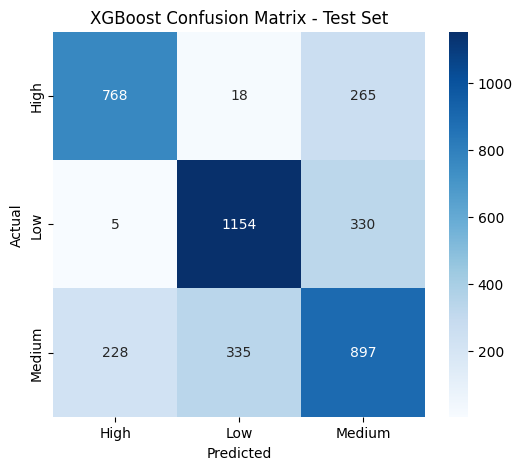

In [20]:
cm = confusion_matrix(y_test_encoded, y_test_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Low", "Medium"],
    yticklabels=["High", "Low", "Medium"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix - Test Set")
plt.show()

Feature importance for each position in the 7-observation window:

In [21]:
# XGBoost Feature Importance

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=[f"{feature}_{i+1}" for i in range(WINDOW) for feature in feature_cols]
)

feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(15))

geopolitical_risk_7       0.167364
Port_Congestion_7         0.089314
geopolitical_risk_6       0.031965
Supplier_Reliability_7    0.030504
weather_severity_7        0.029808
Demand_Volatility_7       0.022124
Supplier_Reliability_6    0.021781
geopolitical_risk_5       0.020407
Demand_Volatility_6       0.018206
weather_severity_6        0.016755
Demand_Volatility_5       0.015082
weather_severity_5        0.014382
Supplier_Reliability_3    0.013491
Demand_Volatility_4       0.013477
Supplier_Reliability_5    0.013457
dtype: float32


Feature importance aggregated across all 7 positions, per original feature:

In [22]:
# Total importance for each original feature

feature_importance_total = {}

for feature in feature_cols:
    feature_importance_total[feature] = sum(
        feature_importance[f"{feature}_{i}"]
        for i in range(1, WINDOW + 1)
    )

feature_importance_total = pd.Series(
    feature_importance_total
).sort_values(ascending=False)

print(feature_importance_total)

geopolitical_risk                0.262672
Port_Congestion                  0.147142
Supplier_Reliability             0.115160
Demand_Volatility                0.106615
weather_severity                 0.101366
Supplier_Capacity_Utilization    0.069878
Shipping_Cost_Index              0.066895
Inventory_Level                  0.065419
Lead_Time_Days                   0.064854
dtype: float32


## 10. Save Final Model

In [23]:
# Create artifacts folder
os.makedirs("artifacts", exist_ok=True)

# Save the final model
joblib.dump(xgb_model, "artifacts/model.joblib")

# Save model information
model_info = {
    "model": "XGBoost",
    "window_size": WINDOW,
    "features": feature_cols,
    "target": target_col,
    "label_map": label_map,
    "validation_macro_f1": round(
        f1_score(y_val_encoded, y_val_pred_xgb, average="macro"), 4
    ),
    "test_macro_f1": round(
        f1_score(y_test_encoded, y_test_pred_xgb, average="macro"), 4
    )
}

with open("artifacts/model_info.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Model saved successfully.")
print("artifacts/model.joblib")
print("artifacts/model_info.json")


Model saved successfully.
artifacts/model.joblib
artifacts/model_info.json
